In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_8.0/DN_FLUXDRIVEN_GAM_CIRCULARTEST_Q3.5";
delta_t = reader.fetch_delta_t(directory_path);
data_arrays = reader.fetch_phi2D_data(directory_path);

Found 26401 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Compiled data from 2000 files...
Compiled data from 3000 files...
Compiled data from 4000 files...
Compiled data from 5000 files...
Compiled data from 6000 files...
Compiled data from 7000 files...
Compiled data from 8000 files...
Compiled data from 9000 files...
Compiled data from 10000 files...
Compiled data from 11000 files...
Compiled data from 12000 files...
Compiled data from 13000 files...
Compiled data from 14000 files...
Compiled data from 15000 files...
Compiled data from 16000 files...
Compiled data from 17000 files...
Compiled data from 18000 files...
Compiled data from 19000 files...
Compiled data from 20000 files...
Compiled data from 21000 files...
Compiled data from 22000 files...
Compiled data from 23000 files...
Compiled data from 24000 files...
Compiled data from 25000 files...
Compiled data from 26000 files...
Finished compiling data from all files in the directory.


In [5]:
print(data_arrays[0].dims, data_arrays[0].shape);

('theta', 'r') (129, 128)


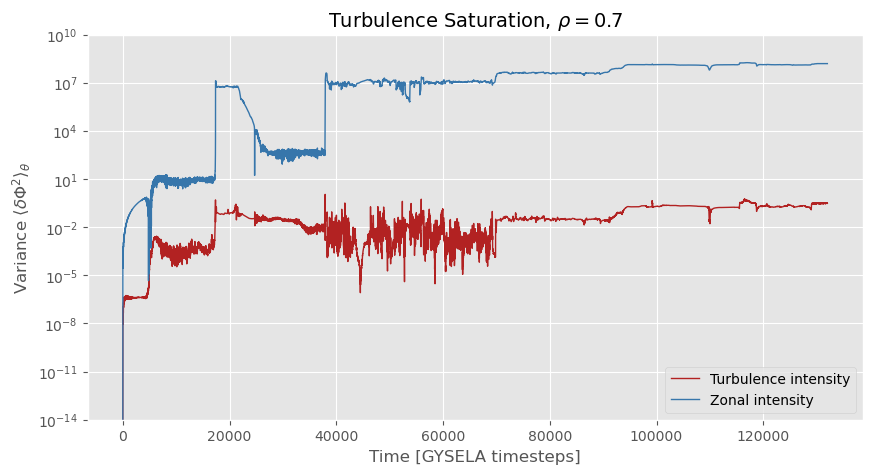

In [7]:
def generate_turbulent_variance_time_series(phi2D_list, effective_radius = None):

	# Cull zonal component to extract turbulence intensity.
	operation = lambda entry: ((entry - entry.mean(dim="theta")) ** 2).mean(dim="theta");
	radial_strips = [operation(phi2D_xarray) for phi2D_xarray in phi2D_list];
	variance_series = xr.concat(radial_strips, dim = "time");

	if not effective_radius is None:
		variance_series = utils.slice_at_effective_radius(variance_series, effective_radius);

	return variance_series;

def generate_zonal_time_series(phi2D_list, effective_radius = None):

	# Take a simple poloidal average and square to isolate zonal mode intensities.
	operation = lambda entry: entry.mean(dim = "theta") ** 2;
	radial_strips = [operation(phi2D_xarray) for phi2D_xarray in phi2D_list];
	zonal_series = xr.concat(radial_strips, dim = "time");

	if not effective_radius is None:
		zonal_series = utils.slice_at_effective_radius(zonal_series, effective_radius);

	return zonal_series;

def plot_turbulence_saturation(phi2D_list, delta_t, dt_diag, effective_radius, log_scale = False):

	variance_series = generate_turbulent_variance_time_series(phi2D_list, effective_radius);
	zonal_series = generate_zonal_time_series(phi2D_list, effective_radius);
	stride = utils.calculate_stride(delta_t, dt_diag);
	time_range = np.arange(len(variance_series)) * stride;

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	operation = plt.semilogy if log_scale else plt.plot;
	operation(time_range, variance_series, color = "firebrick", lw = 1.0, label = "Turbulence intensity");
	operation(time_range, zonal_series, color = "#3776ab", lw = 1.0, label = "Zonal intensity");
	plt.title(f"Turbulence Saturation, $\\rho = {effective_radius}$", fontsize = 14);
	plt.xlabel("Time [GYSELA timesteps]", fontsize = 12);
	plt.ylabel(r"Variance $\langle \delta \Phi^2 \rangle_\theta$", fontsize = 12);
	plt.ylim(10e-15, 10e9);
	plt.legend();
	plt.show();

plot_turbulence_saturation(data_arrays, delta_t, dt_diag = 125, effective_radius = 0.7, log_scale = True);